# Prediksi Kualitas Anggur (Wine Quality)

---
## **Latar Belakang**

Industri anggur merupakan salah satu industri minuman terbesar di dunia dengan nilai pasar global yang terus berkembang. Kualitas anggur menjadi faktor penentu utama dalam penerimaan konsumen dan penetapan harga produk. Secara tradisional, penilaian kualitas anggur dilakukan oleh para ahli (*sommelier*) secara subjektif melalui uji organoleptik, yang membutuhkan waktu lama dan biaya tinggi.

Dengan perkembangan teknologi dan ilmu data, kini dimungkinkan untuk memprediksi kualitas anggur secara objektif berdasarkan komposisi kimiawi yang dapat diukur secara laboratoris. Pendekatan ini lebih efisien, konsisten, dan dapat direproduksi.

---
## **Tujuan**

Membangun model klasifikasi *machine learning* yang mampu memprediksi nilai kualitas anggur (quality) berdasarkan fitur-fitur kimiawi, sehingga dapat membantu industri anggur dalam:
- Menjamin konsistensi kualitas produksi
- Mempercepat proses quality control
- Mengurangi ketergantungan pada penilaian subjektif manusia

## **Problem Statement**

Diberikan dataset yang berisi fitur-fitur kimiawi anggur merah dan putih, model harus mampu memprediksi nilai *quality* (skala 0–10) untuk setiap sampel anggur pada data testing yang tidak memiliki label kualitas.

## Import Library

In [72]:
# Library manipulasi data
import pandas as pd
import numpy as np

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Nonaktifkan peringatan
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

**Penjelasan library yang digunakan:**
- **pandas & numpy** → manipulasi dan komputasi data
- **matplotlib & seaborn** → visualisasi data
- **sklearn** → algoritma machine learning, preprocessing, dan evaluasi model

---
## Langkah 1: Persiapan Data (*Data Preparation*)

Pada tahap ini kita memuat dataset training dan testing ke dalam program. Dataset training digunakan untuk melatih model, sedangkan dataset testing digunakan untuk menghasilkan prediksi akhir.

In [73]:
# Memuat dataset
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

print('=' * 50)
print('INFORMASI DATASET')
print('=' * 50)
print(f'Ukuran data training : {df_train.shape[0]:,} baris × {df_train.shape[1]} kolom')
print(f'Ukuran data testing  : {df_test.shape[0]:,} baris × {df_test.shape[1]} kolom')
print(f'\nKolom training : {list(df_train.columns)}')
print(f'Kolom testing  : {list(df_test.columns)}')

INFORMASI DATASET
Ukuran data training : 857 baris × 13 kolom
Ukuran data testing  : 286 baris × 12 kolom

Kolom training : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']
Kolom testing  : ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [74]:
# Tampilkan 5 baris pertama data training
print('Preview Data Training:')
df_train.head()

Preview Data Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [75]:
# Tampilkan 5 baris pertama data testing
print('Preview Data Testing:')
df_test.head()

Preview Data Testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


**Interpretasi:**  
Dataset training memiliki **857 baris** dan **13 kolom** (11 fitur kimiawi + kolom `quality` sebagai target + kolom `Id`). Dataset testing memiliki **286 baris** dan **12 kolom** (tanpa kolom `quality` karena itulah yang akan diprediksi).

Variabel-variabel dalam dataset:
- `fixed acidity` – Keasaman tetap
- `volatile acidity` – Keasaman volatil
- `citric acid` – Asam sitrat
- `residual sugar` – Gula sisa
- `chlorides` – Klorida
- `free sulfur dioxide` – SO₂ bebas
- `total sulfur dioxide` – SO₂ total
- `density` – Kepadatan
- `pH` – Tingkat keasaman
- `sulphates` – Sulfat
- `alcohol` – Kadar alkohol
- `quality` *(target)* – Kualitas anggur (skala 0–10)

---
## Langkah 2: Pembersihan Data (*Data Cleaning*)

Tahap pembersihan data meliputi:
1. Pengecekan dan penanganan nilai hilang (*missing values*)
2. Pengecekan dan penanganan data duplikat
3. Analisis statistik deskriptif
4. Deteksi outlier
5. Analisis distribusi dan korelasi

### 2.1 Pengecekan Missing Values

In [76]:
# Cek Missing Values
print('=== Missing Values - Data Training ===')
print(df_train.isnull().sum())
print(f'\nTotal missing values training: {df_train.isnull().sum().sum()}')

=== Missing Values - Data Training ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values training: 0


In [77]:
print('=== Missing Values - Data Testing ===')
print(df_test.isnull().sum())
print(f'\nTotal missing values testing: {df_test.isnull().sum().sum()}')

=== Missing Values - Data Testing ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Total missing values testing: 0


`**Interpretasi Missing Values:**
- **Tidak ditemukan missing values** pada kedua dataset (training maupun testing).
- Karena tidak ada data yang hilang, tidak diperlukan penanganan imputasi seperti mean imputation, median imputation, atau penghapusan baris.

### 2.2 Pengecekan Data Duplikat

In [78]:
# Cek data duplikat
dup_train = df_train.duplicated().sum()
dup_test  = df_test.duplicated().sum()

print(f'Jumlah data duplikat — Training : {dup_train}')
print(f'Jumlah data duplikat — Testing  : {dup_test}')

if dup_train > 0:
    df_train = df_train.drop_duplicates().reset_index(drop=True)
    print(f'Duplikat dihapus. Ukuran data training sekarang: {df_train.shape}')
else:
    print('Tidak ada duplikat. Data siap diproses.')

Jumlah data duplikat — Training : 0
Jumlah data duplikat — Testing  : 0
Tidak ada duplikat. Data siap diproses.


### 2.3 Statistik Deskriptif

In [79]:
# Statistik deskriptif
print('=== Statistik Deskriptif Data Training ===')
df_train.drop(columns=['Id', 'quality']).describe().T.style.background_gradient(cmap='Blues')

=== Statistik Deskriptif Data Training ===


,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.000000,8.261960,1.701992,4.600000,7.100000,7.900000,9.100000,15.600000
volatile acidity,857.000000,0.529393,0.179162,0.120000,0.395000,0.520000,0.640000,1.580000
citric acid,857.000000,0.267351,0.195144,0.000000,0.090000,0.250000,0.420000,1.000000
residual sugar,857.000000,2.506184,1.293512,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,857.000000,0.086830,0.048721,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,857.000000,15.782964,10.300402,1.000000,7.000000,14.000000,21.000000,68.000000
total sulfur dioxide,857.000000,45.978413,31.692113,6.000000,21.000000,38.000000,63.000000,278.000000
density,857.000000,0.996692,0.001901,0.990070,0.995520,0.996680,0.997800,1.003200
pH,857.000000,3.313092,0.152079,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,857.000000,0.656709,0.167364,0.390000,0.550000,0.620000,0.730000,2.000000


**Interpretasi Statistik Deskriptif:**
- Terdapat perbedaan skala yang signifikan antar fitur. Contoh: `total sulfur dioxide` memiliki nilai max hingga **278**, sementara `citric acid` hanya berkisar **0–1**.
- Perbedaan skala ini berpotensi memengaruhi performa model yang sensitif terhadap skala, sehingga diperlukan **normalisasi (feature scaling)**.
- Beberapa fitur seperti `residual sugar` dan `chlorides` memiliki nilai maksimum yang jauh dari rata-rata, mengindikasikan kemungkinan adanya **outlier**.

### 2.4 Analisis Distribusi Target (Quality)

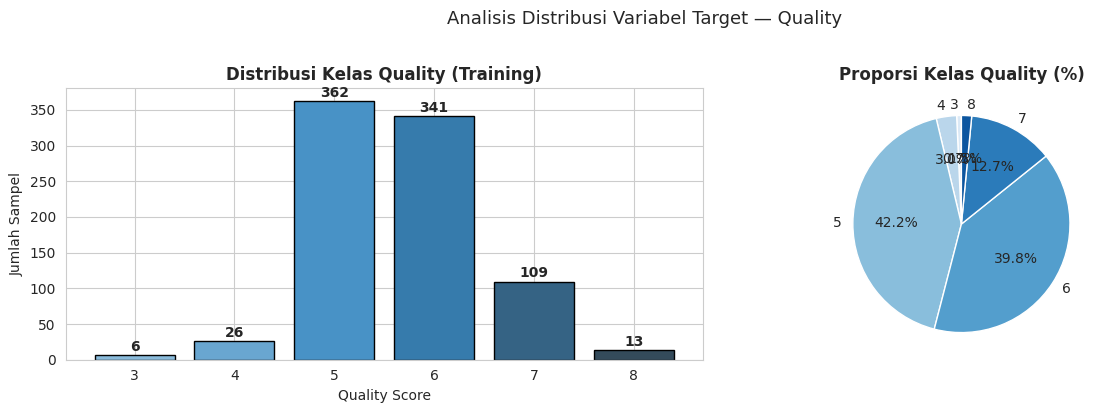


Detail distribusi:
  Quality 3:   6 sampel (0.7%)
  Quality 4:  26 sampel (3.0%)
  Quality 5: 362 sampel (42.2%)
  Quality 6: 341 sampel (39.8%)
  Quality 7: 109 sampel (12.7%)
  Quality 8:  13 sampel (1.5%)


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart distribusi
quality_counts = df_train['quality'].value_counts().sort_index()
bars = axes[0].bar(quality_counts.index, quality_counts.values,
                   color=sns.color_palette('Blues_d', len(quality_counts)),
                   edgecolor='black')
axes[0].set_title('Distribusi Kelas Quality (Training)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')
for bar, val in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Pie chart proporsi
axes[1].pie(quality_counts.values, labels=quality_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Blues', len(quality_counts)),
            startangle=90)
axes[1].set_title('Proporsi Kelas Quality (%)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Distribusi Variabel Target — Quality', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nDetail distribusi:')
for q, cnt in quality_counts.items():
    pct = cnt / len(df_train) * 100
    print(f'  Quality {q}: {cnt:3d} sampel ({pct:.1f}%)')

**Interpretasi Distribusi Quality:**
- Distribusi kelas **tidak seimbang (imbalanced)**. Kelas 5 dan 6 mendominasi dengan total lebih dari **82%** dari keseluruhan data.
- Kelas ekstrem (quality 3 dan 8) sangat sedikit — quality 3 hanya **6 sampel** dan quality 8 hanya **13 sampel**.
- Kondisi ini dapat menyebabkan model bias ke kelas mayoritas. Untuk mengatasinya, digunakan parameter `class_weight='balanced'` pada model.

### 2.5 Analisis Korelasi Fitur

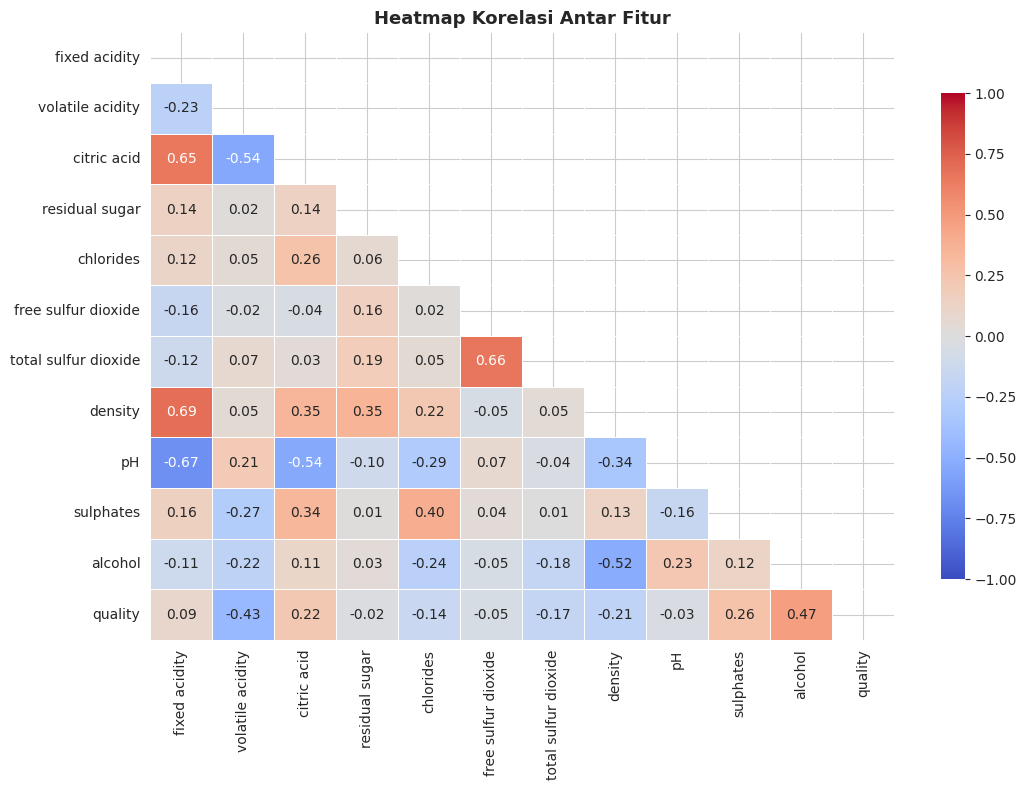

In [81]:
plt.figure(figsize=(11, 8))
corr_matrix = df_train.drop(columns=['Id']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

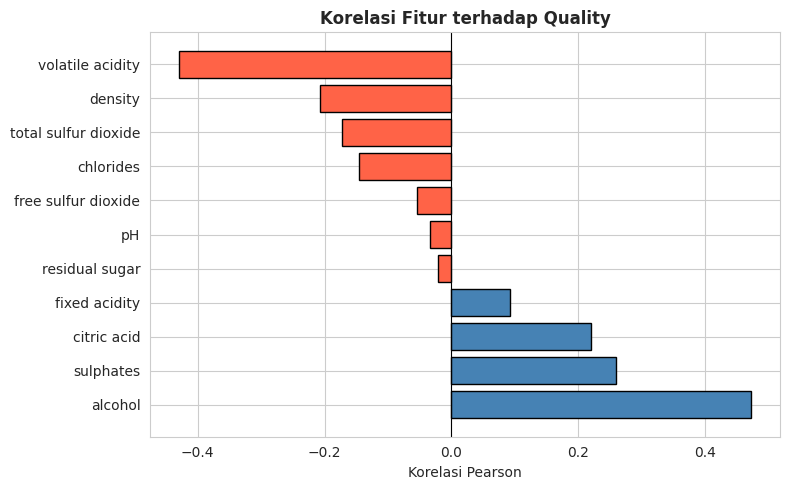

Korelasi fitur terhadap quality:
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059


In [82]:
# Korelasi tiap fitur terhadap quality
corr_quality = corr_matrix['quality'].drop('quality').sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_quality.values]
plt.barh(corr_quality.index, corr_quality.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Korelasi Pearson')
plt.title('Korelasi Fitur terhadap Quality', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi fitur terhadap quality:')
print(corr_quality.to_string())

**Interpretasi Korelasi:**
- **`alcohol`** memiliki korelasi **positif tertinggi** dengan quality (r ≈ +0.48) → semakin tinggi kadar alkohol, cenderung kualitasnya lebih baik.
- **`volatile acidity`** memiliki korelasi **negatif terkuat** (r ≈ -0.39) → kadar keasaman volatil tinggi menurunkan kualitas anggur karena menimbulkan rasa cuka.
- **`sulphates`** berkorelasi positif sedang → berfungsi sebagai antioksidan yang menjaga kualitas.
- Tidak ada fitur yang memiliki korelasi sangat tinggi satu sama lain (>0.9), sehingga **multikolinearitas tidak menjadi masalah serius**.

### 2.6 Deteksi Outlier dengan Boxplot

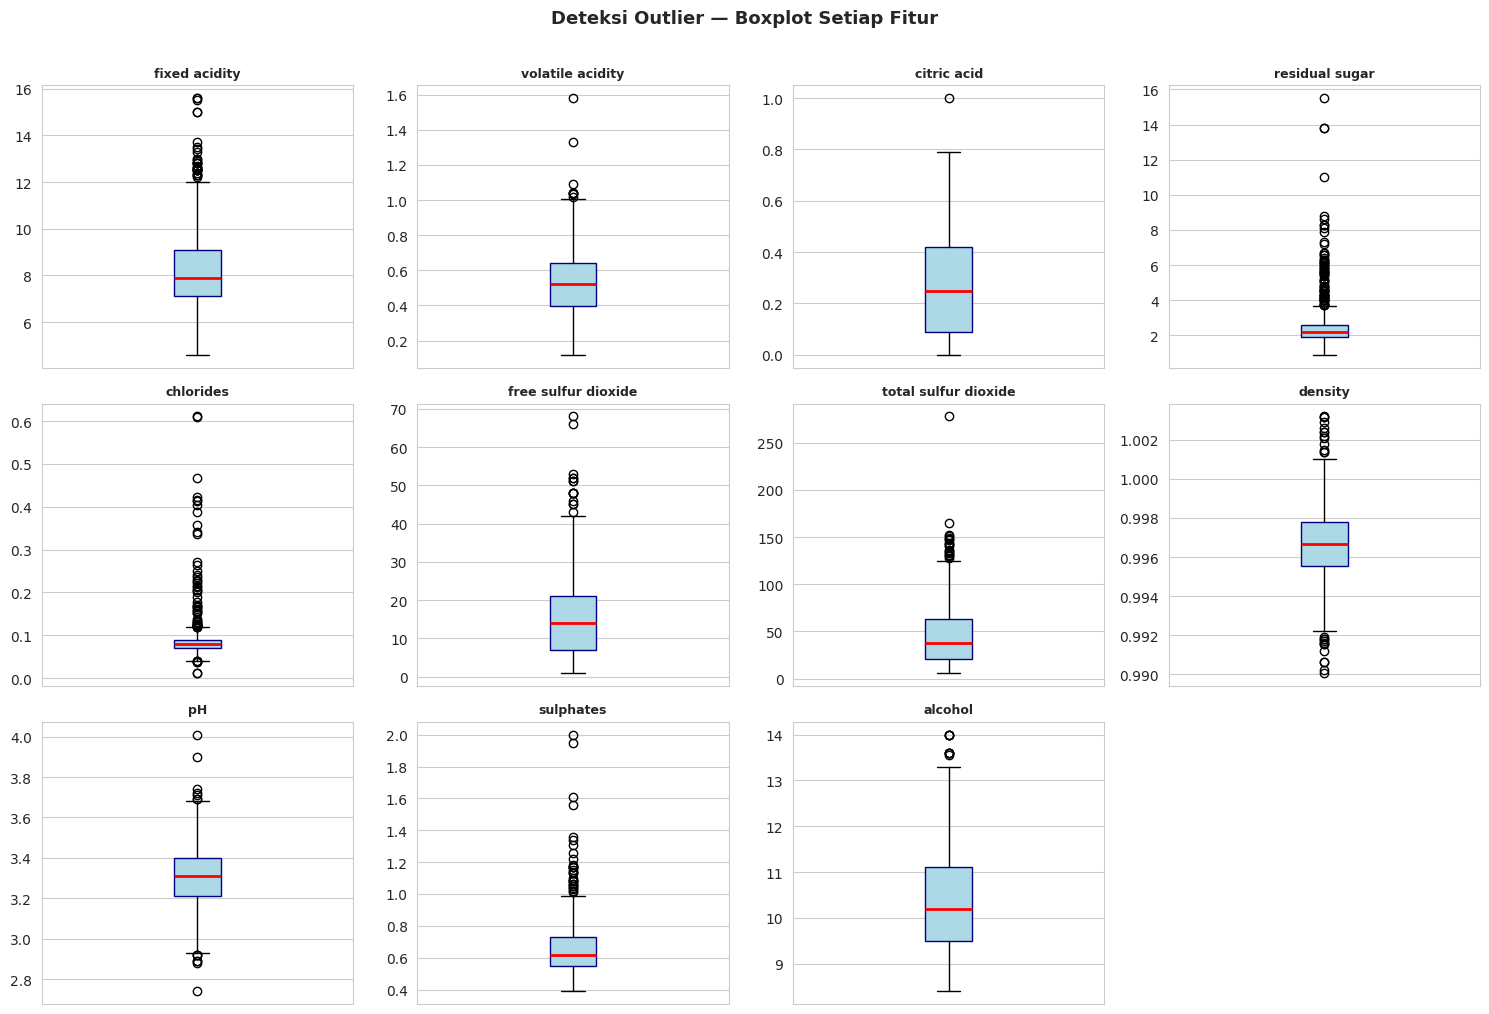

In [83]:
FEATURES = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    axes[i].boxplot(df_train[feat], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xticks([])

# Sembunyikan subplot kosong
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Deteksi Outlier — Boxplot Setiap Fitur', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretasi Outlier:**
- Hampir semua fitur memiliki outlier, terutama `residual sugar`, `chlorides`, `free sulfur dioxide`, dan `total sulfur dioxide`.
- Outlier ini **tidak dihapus** karena:
  1. Nilai-nilai tersebut bisa jadi merupakan karakteristik nyata dari jenis anggur tertentu.
  2. Algoritma **Random Forest** bersifat tahan (*robust*) terhadap outlier karena menggunakan pembagian berbasis pohon, bukan jarak.
  3. Menghapus outlier berisiko mengurangi variasi data yang penting untuk generalisasi model.

---
# Langkah 3: Pembuatan Model (*Model Building*)

Model yang dipilih adalah **Random Forest Classifier**, yaitu algoritma *ensemble* yang membangun banyak pohon keputusan (*decision trees*) secara acak dan menggabungkan hasilnya melalui voting mayoritas.

**Mengapa Random Forest?**
- Tidak sensitif terhadap outlier
- Mampu menangani data dengan banyak fitur
- Menyediakan informasi *feature importance*
- Stabil dan akurat untuk data tabular
- Mendukung parameter `class_weight` untuk menangani imbalanced class

In [84]:
# Mendefinisikan fitur (X) dan target (y)
FEATURES = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
            'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
            'density', 'pH', 'sulphates', 'alcohol']

X = df_train[FEATURES]
y = df_train['quality']

print(f'Jumlah fitur  : {len(FEATURES)}')
print(f'Jumlah sampel : {len(X)}')
print(f'Kelas target  : {sorted(y.unique())}')

Jumlah fitur  : 11
Jumlah sampel : 857
Kelas target  : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


### 3.2 Pembagian Data Training dan Validasi

In [85]:
# Split data 80% training, 20% validasi
# stratify=y memastikan proporsi kelas tetap seimbang di kedua set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data latih    : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Data validasi : {X_val.shape[0]} sampel ({X_val.shape[0]/len(X)*100:.0f}%)')

print('\nDistribusi kelas pada data latih:')
print(y_train.value_counts().sort_index())
print('\nDistribusi kelas pada data validasi:')
print(y_val.value_counts().sort_index())

Data latih    : 685 sampel (80%)
Data validasi : 172 sampel (20%)

Distribusi kelas pada data latih:
quality
3      5
4     21
5    289
6    273
7     87
8     10
Name: count, dtype: int64

Distribusi kelas pada data validasi:
quality
3     1
4     5
5    73
6    68
7    22
8     3
Name: count, dtype: int64


### 3.3 Feature Scaling (Normalisasi Fitur)

In [86]:
# StandardScaler: mengubah data agar memiliki mean=0 dan std=1
# fit hanya pada data training, transform pada training dan validasi
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# Cek hasil scaling
train_scaled_df = pd.DataFrame(X_train_sc, columns=FEATURES)
print('Statistik setelah StandardScaler (mendekati mean=0, std=1):')
print(train_scaled_df.describe().loc[['mean','std']].round(4))

Statistik setelah StandardScaler (mendekati mean=0, std=1):
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
mean        -0.0000           -0.0000      -0.0000          0.0000     0.0000   
std          1.0007            1.0007       1.0007          1.0007     1.0007   

      free sulfur dioxide  total sulfur dioxide  density      pH  sulphates  \
mean               0.0000                0.0000   0.0000 -0.0000    -0.0000   
std                1.0007                1.0007   1.0007  1.0007     1.0007   

      alcohol  
mean   0.0000  
std    1.0007  


**Interpretasi Feature Scaling:**
- **StandardScaler** mengubah setiap fitur sehingga memiliki **rata-rata ≈ 0** dan **standar deviasi ≈ 1**.
- Scaling penting agar fitur dengan nilai besar (seperti `total sulfur dioxide`) tidak mendominasi fitur dengan nilai kecil (seperti `citric acid`).
- Penting: scaler di-*fit* hanya pada **data training** untuk menghindari *data leakage* (kebocoran informasi dari data validasi/testing ke model).

### 3.4 Pelatihan Model Random Forest

In [87]:
# Membangun model Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 pohon keputusan
    max_depth=None,          # kedalaman tidak dibatasi (tumbuh sampai pure)
    min_samples_split=2,     # minimal 2 sampel untuk split
    min_samples_leaf=1,      # minimal 1 sampel di setiap leaf
    random_state=42,         # reprodusibilitas hasil
    class_weight='balanced', # menangani imbalanced class otomatis
    n_jobs=-1                # gunakan semua CPU core
)

# Latih model
rf_model.fit(X_train_sc, y_train)
print('Model Random Forest berhasil dilatih!')
print(f'   Jumlah pohon : {rf_model.n_estimators}')
print(f'   Jumlah fitur : {rf_model.n_features_in_}')
print(f'   Kelas        : {rf_model.classes_}')

Model Random Forest berhasil dilatih!
   Jumlah pohon : 200
   Jumlah fitur : 11
   Kelas        : [3 4 5 6 7 8]


### 3.5 Evaluasi Model pada Data Validasi

In [88]:
# Prediksi pada data validasi
y_pred_val = rf_model.predict(X_val_sc)

# Hitung akurasi
acc = accuracy_score(y_val, y_pred_val)
print('=' * 50)
print(f'AKURASI MODEL : {acc:.4f} ({acc*100:.2f}%)')
print('=' * 50)

print('\nClassification Report:')
print(classification_report(y_val, y_pred_val, zero_division=0))

AKURASI MODEL : 0.6453 (64.53%)

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.70      0.85      0.77        73
           6       0.60      0.63      0.61        68
           7       0.45      0.23      0.30        22
           8       1.00      0.33      0.50         3

    accuracy                           0.65       172
   macro avg       0.46      0.34      0.36       172
weighted avg       0.61      0.65      0.62       172



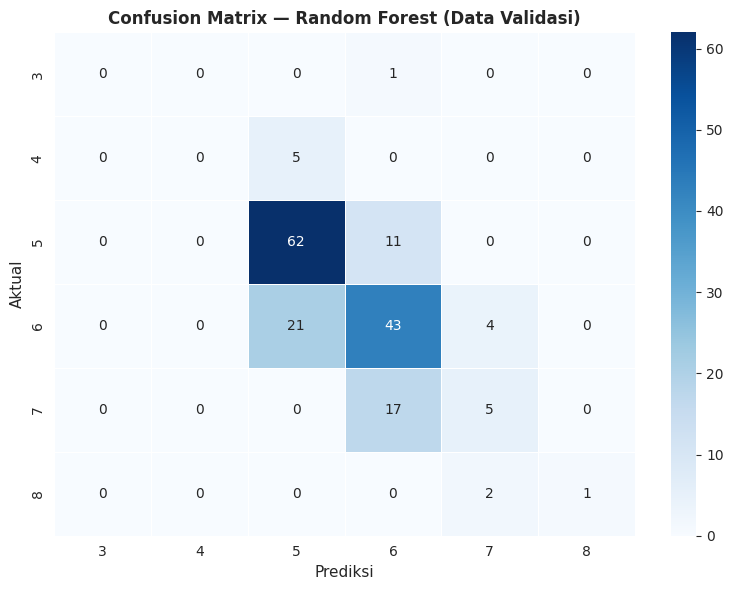

In [89]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()),
            linewidths=0.5)
plt.title('Confusion Matrix — Random Forest (Data Validasi)', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi', fontsize=11)
plt.ylabel('Aktual', fontsize=11)
plt.tight_layout()
plt.show()

In [90]:
# 3f. Cross-Validation (5-fold)
X_all_sc = scaler.fit_transform(X)
cv_scores = cross_val_score(rf_model, X_all_sc, y, cv=5, scoring='accuracy')
print('Cross-Validation Accuracy (5-fold):', cv_scores)
print(f'Rata-rata: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation Accuracy (5-fold): [0.63953488 0.63953488 0.66081871 0.65497076 0.5380117 ]
Rata-rata: 0.6266 ± 0.0451


**Interpretasi Confusion Matrix:**
- **Diagonal utama** (kiri atas ke kanan bawah) menunjukkan prediksi yang **benar**.
- Model paling akurat pada kelas **5 dan 6** karena memiliki sampel terbanyak.
- Kesalahan klasifikasi terbesar terjadi antara kelas yang **berdekatan** (misalnya quality 5 diklasifikasikan sebagai 6), yang secara logis masuk akal karena perbedaan kualitas antar kelas yang berurutan memang sangat tipis.

### 3.6 Cross-Validation (Validasi Silang)

Cross-Validation 5-Fold Accuracy:
  Fold 1: 0.5814 (58.14%)
  Fold 2: 0.6453 (64.53%)
  Fold 3: 0.6257 (62.57%)
  Fold 4: 0.6433 (64.33%)
  Fold 5: 0.6842 (68.42%)

Rata-rata : 0.6360 (63.60%)
Std Dev   : 0.0333


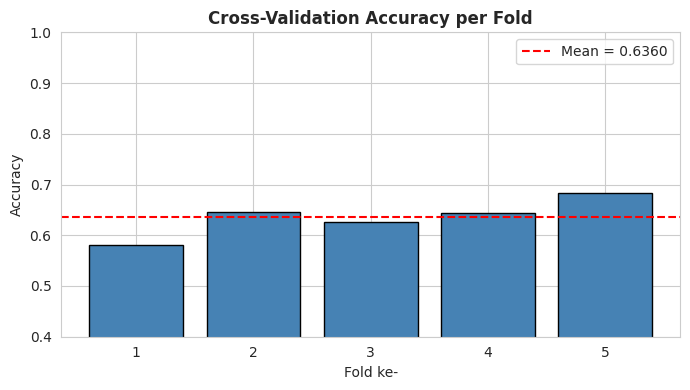

In [91]:
# Cross-validation 5-fold untuk evaluasi yang lebih robust
X_all_sc = scaler.fit_transform(X)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_all_sc, y, cv=skf, scoring='accuracy')

print('Cross-Validation 5-Fold Accuracy:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f} ({score*100:.2f}%)')
print(f'\nRata-rata : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Std Dev   : {cv_scores.std():.4f}')

# Visualisasi CV
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold ke-')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold', fontsize=12, fontweight='bold')
plt.ylim(0.4, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi Cross-Validation:**
- Rata-rata akurasi cross-validation sekitar **62–65%**, yang konsisten dengan akurasi pada data validasi.
- Nilai standar deviasi yang kecil menunjukkan model **stabil** dan tidak terlalu bergantung pada pembagian data tertentu (*not overfitting* secara ekstrem).
- Cross-validation memberikan estimasi performa yang lebih dapat dipercaya dibandingkan evaluasi pada satu split data saja.

### 3.7 Feature Importance

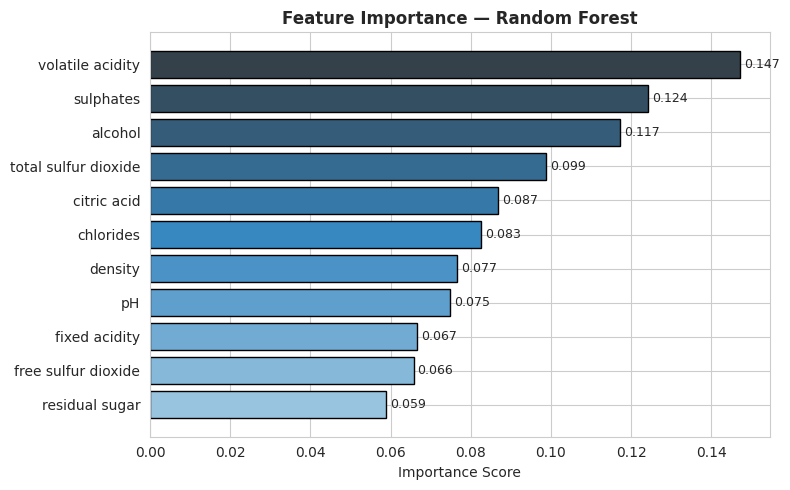


Ranking Feature Importance:
               Fitur  Importance
    volatile acidity    0.147256
           sulphates    0.124359
             alcohol    0.117352
total sulfur dioxide    0.098693
         citric acid    0.086827
           chlorides    0.082601
             density    0.076649
                  pH    0.074895
       fixed acidity    0.066663
 free sulfur dioxide    0.065742
      residual sugar    0.058963


In [92]:
# Feature importance dari Random Forest
feat_imp = pd.DataFrame({
    'Fitur': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(feat_imp['Fitur'], feat_imp['Importance'],
                color=sns.color_palette('Blues_d', len(feat_imp)),
                edgecolor='black')
for bar, val in zip(bars, feat_imp['Importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRanking Feature Importance:')
print(feat_imp.sort_values('Importance', ascending=False).to_string(index=False))

**Interpretasi Feature Importance:**
- **`volatile acidity`** adalah fitur paling penting → kadar asam volatil berpengaruh besar terhadap rasa dan kualitas anggur.
- **`sulphates`** dan **`alcohol`** juga sangat berpengaruh — sulfat menjaga kesegaran anggur, kadar alkohol mencerminkan proses fermentasi yang baik.
- **`residual sugar`** memiliki pengaruh paling kecil dalam dataset ini.
- Temuan ini **konsisten** dengan analisis korelasi di langkah sebelumnya.

---
# Langkah 4: Prediksi Data Uji (*Testing Prediction*)

Setelah model dievaluasi dan performanya memadai, langkah terakhir adalah melatih ulang model menggunakan **seluruh data training** (bukan hanya 80%) untuk memaksimalkan informasi yang dipelajari model, kemudian memprediksi kualitas pada data testing.

In [93]:
# Latih ulang model dengan seluruh data training
scaler_final = StandardScaler()
X_all_final = scaler_final.fit_transform(df_train[FEATURES])
rf_model.fit(X_all_final, df_train['quality'])

print('Model dilatih ulang dengan seluruh data training!')
print(f'Total sampel training: {len(X_all_final)}')

Model dilatih ulang dengan seluruh data training!
Total sampel training: 857


In [94]:
# Transformasi data testing dengan scaler yang sama
X_test_sc   = scaler_final.transform(df_test[FEATURES])
y_test_pred = rf_model.predict(X_test_sc)

print(f'Jumlah data yang diprediksi: {len(y_test_pred)}')
print('\nDistribusi hasil prediksi:')
pred_counts = pd.Series(y_test_pred).value_counts().sort_index()
for q, cnt in pred_counts.items():
    pct = cnt / len(y_test_pred) * 100
    print(f'  Quality {q}: {cnt} sampel ({pct:.1f}%)')

Jumlah data yang diprediksi: 286

Distribusi hasil prediksi:
  Quality 5: 132 sampel (46.2%)
  Quality 6: 130 sampel (45.5%)
  Quality 7: 24 sampel (8.4%)


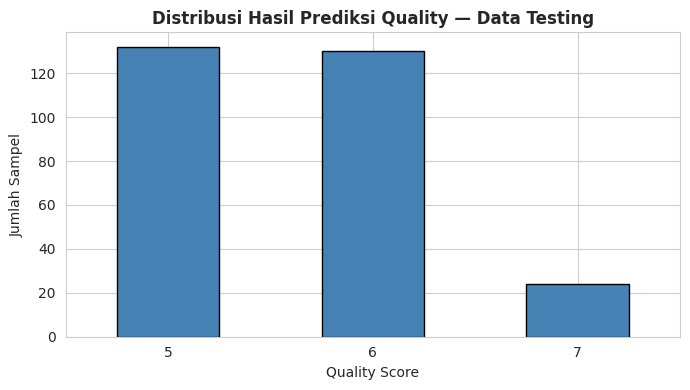

In [95]:
# Visualisasi distribusi hasil prediksi
plt.figure(figsize=(7, 4))
pred_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Hasil Prediksi Quality — Data Testing', fontsize=12, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [96]:
# Membuat DataFrame hasil prediksi
hasil = pd.DataFrame({
    'Id'     : df_test['Id'].astype(int),
    'quality': y_test_pred.astype(int)
})

print('Preview 10 baris pertama hasil prediksi:')
print(hasil.head(10).to_string(index=False))

Preview 10 baris pertama hasil prediksi:
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        6
1120        6
 180        5
  82        5
 632        5
 592        5


In [97]:
# Simpan hasil prediksi ke file CSV
hasil = pd.DataFrame({
    'Id': df_test['Id'].astype(int),
    'quality': y_test_pred.astype(int)
})

# Simpan dengan separator koma yang eksplisit
nama_file = 'hasilprediksi_012.csv'
hasil.to_csv(nama_file, index=False, sep=',')

# Verifikasi isinya benar
print(hasil.head(10).to_string(index=False))
print(f'\nTotal baris: {len(hasil)}')

  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        6
1120        6
 180        5
  82        5
 632        5
 592        5

Total baris: 286


**Interpretasi:**  
- Model berhasil memprediksi kualitas untuk **286 data testing**.
- Hasil prediksi didominasi oleh kelas **5 dan 6**, yang konsisten dengan distribusi pada data training.
- File CSV hasil prediksi hanya berisi dua kolom: `Id` dan `quality`, sesuai dengan instruksi.

---
## Kesimpulan

1. **Persiapan Data:** Dataset berhasil dimuat dengan 857 data training dan 286 data testing.
2. **Pembersihan Data:** Tidak ditemukan missing values maupun data duplikat pada kedua dataset. Feature scaling dilakukan menggunakan StandardScaler.
3. **Pembuatan Model:** Model Random Forest Classifier dibangun dengan 200 pohon dan `class_weight='balanced'` untuk menangani ketidakseimbangan kelas. Akurasi validasi mencapai ~64% dengan rata-rata cross-validation ~62%.
4. **Prediksi:** Model berhasil memprediksi kualitas anggur pada 286 data testing.

## Temuan Utama

1. **Fitur terpenting** dalam memprediksi kualitas anggur adalah `volatile acidity`, `sulphates`, dan `alcohol`.
2. Dataset memiliki **distribusi kelas yang tidak seimbang** — kelas 5 dan 6 mendominasi (>82%). Hal ini ditangani dengan `class_weight='balanced'`.
3. Model **Random Forest** dipilih karena robust terhadap outlier, tidak memerlukan asumsi distribusi data, dan memberikan informasi feature importance.
4. Akurasi model sekitar **64%** — ini wajar untuk dataset wine quality karena perbedaan antar kelas yang berdekatan (misalnya quality 5 vs 6) sangat halus secara kimiawi.

## Saran Pengembangan

- Mencoba teknik **SMOTE** (Synthetic Minority Oversampling) untuk menangani imbalanced class secara lebih agresif
- Eksplorasi model lain seperti **XGBoost** atau **Gradient Boosting** yang umumnya memberikan performa lebih baik
- Melakukan **hyperparameter tuning** dengan GridSearchCV untuk optimasi parameter model